## Inspect Pretrain Results

pretrain.py returns multiple weights, and .pkl files, that are compared here.

In [1]:
import pickle
import glob
import os
import matplotlib.pyplot as plt

import json
import argparse
import cv2
import numpy as np
import torch

import re

from networks.corenet import CoRE_Net
from networks.framework import MyFrame
from utils.loss import dice_bce_loss

/home/justs/.conda/envs/vein_segment/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [3]:
def get_latest_result_dir(results_root='./results'):
    pattern = os.path.join(results_root, 'ds_*-lr_*-*')
    candidates = glob.glob(pattern)

    # extract timestamp from folder name: ds_10-lr_0.03-2026-09-18_10-58-23-NGbYLahx
    ts_re = re.compile(r'-(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})-')

    dated = []
    for path in candidates:
        name = os.path.basename(path)
        m = ts_re.search(name)
        if m:
            dated.append((m.group(1), path))

    if not dated:
        raise FileNotFoundError(f'No matching result folders found in {results_root}')

    dated.sort(key=lambda x: x[0])  # timestamp string sorts chronologically
    latest_path = dated[-1][1]
    return latest_path

In [26]:
exp_dir = get_latest_result_dir(results_root='./results/pretrain/')
exp_dir = './results/pretrain/ds_32-lr_1e-06-2026-09-29_11-06-31-vk7oAm51'

In [15]:
def to_scalar(x):
    return x.item() if hasattr(x, 'item') else x

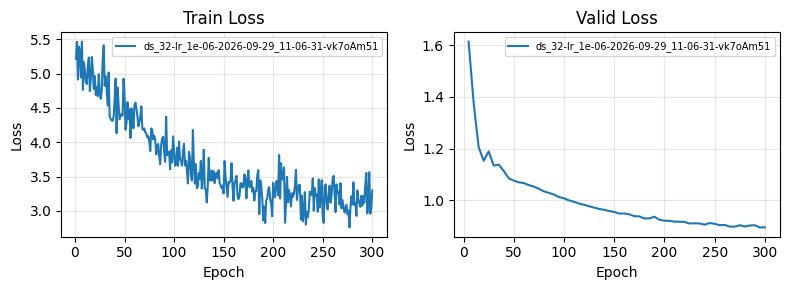

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

pkl_path = os.path.join(exp_dir, 'result.pkl')
with open(pkl_path, 'rb') as f:
    record = pickle.load(f)

label = os.path.basename(exp_dir)

train_epochs = sorted(record['train'].keys())
train_losses = [to_scalar(record['train'][e]['train_loss']) for e in train_epochs]
axes[0].plot(train_epochs, train_losses, label=label)

valid_epochs = sorted(record['valid'].keys())
valid_losses = [to_scalar(record['valid'][e]['valid_loss']) for e in valid_epochs]
axes[1].plot(valid_epochs, valid_losses, label=label)

axes[0].set_title('Train Loss')
axes[1].set_title('Valid Loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
#-plt.savefig('loss_curves.png', dpi=150)
plt.show()

In [28]:
valid_losses = [(e, record['valid'][e]['valid_loss'].item()) for e in sorted(record['valid'].keys())]
for e, l in valid_losses:
    print(e, l)

5 1.6136999130249023
10 1.3781867027282715
15 1.2058528661727905
20 1.1532108783721924
25 1.1890383958816528
30 1.134385347366333
35 1.1378507614135742
40 1.1136566400527954
45 1.0850108861923218
50 1.0762810707092285
55 1.0695836544036865
60 1.0668364763259888
65 1.0587222576141357
70 1.0531187057495117
75 1.0445464849472046
80 1.034571886062622
85 1.028670072555542
90 1.022204875946045
95 1.0125398635864258
100 1.0077532529830933
105 0.9996352791786194
110 0.9942992925643921
115 0.9875210523605347
120 0.982711911201477
125 0.9769102931022644
130 0.9718323945999146
135 0.9666551351547241
140 0.9633308053016663
145 0.9584832191467285
150 0.9551352262496948
155 0.948881983757019
160 0.949091374874115
165 0.9458670616149902
170 0.9387575387954712
175 0.9378666281700134
180 0.9300194978713989
185 0.9301286935806274
190 0.93663489818573
195 0.924616813659668
200 0.9213661551475525
205 0.9206329584121704
210 0.9175165891647339
215 0.917319655418396
220 0.9162050485610962
225 0.9103612899780

In [29]:
# rebuild args from the saved config
with open(f'{exp_dir}/config.json') as f:
    cfg = json.load(f)

In [30]:
valid_losses = [(e, record['valid'][e]['valid_loss'].item()) for e in sorted(record['valid'].keys())]
best_epoch, best_loss = min(valid_losses, key=lambda x: x[1])
print(best_epoch, best_loss)

295 0.8951557278633118


In [31]:
args = argparse.Namespace(**cfg)
args.t_total = 1

# build model and load best validation weights
solver = MyFrame(CoRE_Net, dice_bce_loss, args, evalmode=True)
solver.load(f'{exp_dir}/weights/valid.th')
solver.eval()

In [34]:
def predict_mask(solver, img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_norm = img.astype(np.float32) / 255.0 * 3.2 - 1.6   # same normalization as test_one_img_from_path
    img_t = torch.from_numpy(img_norm).permute(2, 0, 1).unsqueeze(0).cuda()  # (1, C, H, W)

    with torch.no_grad():
        result = solver.net.forward(img_t)          # dict, since net is in eval mode
        pred = result['mask_logits'].sigmoid()        # apply sigmoid — logits aren't probabilities

    mask = pred.squeeze().cpu().numpy()
    mask_bin = (mask > 0.78).astype(np.uint8)
    return img, mask, mask_bin

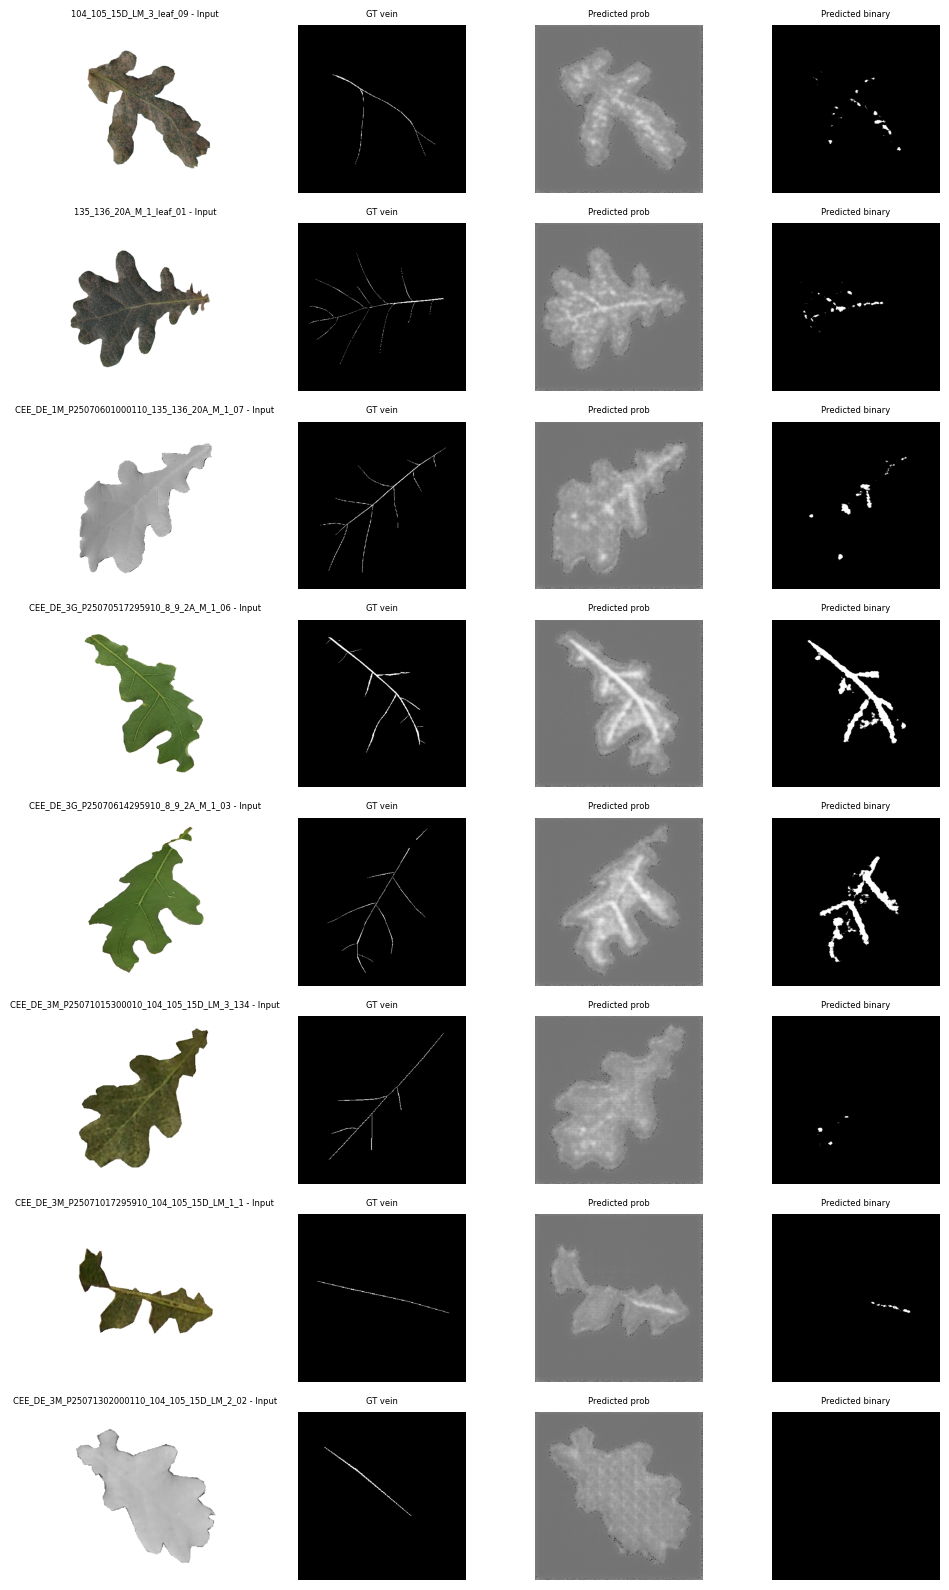

In [35]:
leaf_dirs = sorted(glob.glob(os.path.join(args.data_root, args.dataset, 'test/', '*')))

fig, axes = plt.subplots(len(leaf_dirs), 4, figsize=(10, 2 * len(leaf_dirs)))

for i, leaf_dir in enumerate(leaf_dirs):
    leaf_id = os.path.basename(leaf_dir)
    leaf_path = os.path.join(leaf_dir, 'leaf.png')
    vein_path = os.path.join(leaf_dir, 'vein.png')
    outline_path = os.path.join(leaf_dir, 'outline.png')

    orig, prob_mask, bin_mask = predict_mask(solver, leaf_path)
    gt_vein = cv2.imread(vein_path, cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(orig); axes[i, 0].set_title(f'{leaf_id} - Input', fontsize=6); axes[i, 0].axis('off')
    axes[i, 1].imshow(gt_vein, cmap='gray'); axes[i, 1].set_title('GT vein', fontsize=6); axes[i, 1].axis('off')
    axes[i, 2].imshow(prob_mask, cmap='gray', vmin=0, vmax=1); axes[i, 2].set_title('Predicted prob', fontsize=6); axes[i, 2].axis('off')
    axes[i, 3].imshow(bin_mask, cmap='gray'); axes[i, 3].set_title('Predicted binary', fontsize=6); axes[i, 3].axis('off')

plt.tight_layout()
#-plt.savefig('inference_results.png', dpi=150)
plt.show()

In [41]:
from utils.data_selftrain import ImageFolder

trainset = ImageFolder(root_path='/masc_shared/ag_nauss/projects/phytoakmeter/IEE/vein_segmentation_training_data', datasets='scan_and_photo_labels',
                       mode='retrain', is_random=False)

from types import SimpleNamespace
args = SimpleNamespace(confidence_on=False, point_correction_on=False)

I1005 16:13:33.118113 385372 data_selftrain.py:257] mode: retrain
I1005 16:13:33.118565 385372 data_selftrain.py:280] CEE_DE_3G_P25070519295810_8_9_2A_M_1_03, 0.0
I1005 16:13:33.118894 385372 data_selftrain.py:280] 104_105_15D_LM_3_leaf_134, 1.0
I1005 16:13:33.119202 385372 data_selftrain.py:280] CEE_DE_3M_P25071021000010_104_105_15D_LM_1_5, 2.0
I1005 16:13:33.119504 385372 data_selftrain.py:280] CEE_DE_3M_P25071018300110_104_105_15D_LM_1_17, 3.0
I1005 16:13:33.119789 385372 data_selftrain.py:280] CEE_DE_3G_P25070606595810_8_9_2A_M_1_03, 4.0
I1005 16:13:33.120101 385372 data_selftrain.py:280] CEE_DE_3G_P25070518595910_8_9_2A_M_1_07, 5.0
I1005 16:13:33.120331 385372 data_selftrain.py:280] 104_105_15D_LM_2_leaf_02, 6.0
I1005 16:13:33.120655 385372 data_selftrain.py:280] 104_105_15D_LM_1_leaf_84, 7.0
I1005 16:13:33.120947 385372 data_selftrain.py:280] CEE_DE_3M_P25071021000010_104_105_15D_LM_1_17, 8.0
I1005 16:13:33.121239 385372 data_selftrain.py:280] 135_136_20A_M_1_leaf_03, 9.0
I1005 1

In [43]:
import torch, numpy as np
import utils.infer as my_infer

xy = 0.9
solver.load(f'{exp_dir}/weights/valid.th')
solver.eval()

# actual pseudo-labels, as self_train.py builds them
# (args needs confidence_on=False, point_correction_on=False)
pred_results, b_maps, logits = my_infer.infer_point(
    args, trainset, solver, {'high': 0.99, 'low': 0.05}, 0, 'train')

# raw probabilities, without min-max normalization
raw_list = []
with torch.no_grad():
    for i in range(len(trainset)):
        img, _, _ = trainset[i]
        feats = solver.net._forward_mask_coarse(solver.net.backbone(img[None].cuda()))
        raw_list.append(feats['logits'].sigmoid().squeeze().cpu().numpy())

for t in [0.3, 0.5, 0.7, 0.9]:
    print(t, np.mean([(r >= t).mean() for r in raw_list]))

I1005 16:22:20.876432 385372 infer.py:235] image 0 CEE_DE_3G_P25070519295810_8_9_2A_M_1_03 done
I1005 16:22:20.888116 385372 infer.py:235] image 1 104_105_15D_LM_3_leaf_134 done
I1005 16:22:20.898270 385372 infer.py:235] image 2 CEE_DE_3M_P25071021000010_104_105_15D_LM_1_5 done
I1005 16:22:20.908274 385372 infer.py:235] image 3 CEE_DE_3M_P25071018300110_104_105_15D_LM_1_17 done
I1005 16:22:20.919387 385372 infer.py:235] image 4 CEE_DE_3G_P25070606595810_8_9_2A_M_1_03 done
I1005 16:22:20.929956 385372 infer.py:235] image 5 CEE_DE_3G_P25070518595910_8_9_2A_M_1_07 done
I1005 16:22:20.940155 385372 infer.py:235] image 6 104_105_15D_LM_2_leaf_02 done
I1005 16:22:20.951232 385372 infer.py:235] image 7 104_105_15D_LM_1_leaf_84 done
I1005 16:22:20.964367 385372 infer.py:235] image 8 CEE_DE_3M_P25071021000010_104_105_15D_LM_1_17 done
I1005 16:22:20.974449 385372 infer.py:235] image 9 135_136_20A_M_1_leaf_03 done
I1005 16:22:20.984810 385372 infer.py:235] image 10 CEE_DE_3G_P25070501000010_8_9_2

0.3 1.0
0.5 0.3389369992339608
0.7 0.08971460688262374
0.9 0.01046024888942646


In [47]:
import numpy as np
from utils.metrics import calculate_IoU_Dice
import glog as log

testset = ImageFolder(root_path='/masc_shared/ag_nauss/projects/phytoakmeter/IEE/vein_segmentation_training_data',
                      datasets='scan_and_photo_labels',
                      mode='test',
                      is_random=False)

gts = [testset[i][1].squeeze().numpy() for i in range(len(testset))]
raws = []
with torch.no_grad():
    for i in range(len(testset)):
        img, _, _ = testset[i]
        f = solver.net._forward_mask_coarse(solver.net.backbone(img[None].cuda()))
        raws.append(f['logits'].sigmoid().squeeze().cpu().numpy())

for t in [0.7, 0.8, 0.85, 0.9, 0.95]:
    preds = [(r >= t).astype(np.float32) for r in raws]
    print(t, calculate_IoU_Dice(preds, gts, logger=log)[1]['mDice'])

I1005 16:25:35.518261 385372 data_selftrain.py:257] mode: test
I1005 16:25:35.518774 385372 data_selftrain.py:280] 135_136_20A_M_1_leaf_01, 0.0
I1005 16:25:35.519164 385372 data_selftrain.py:280] CEE_DE_3M_P25071302000110_104_105_15D_LM_2_02, 1.0
I1005 16:25:35.519540 385372 data_selftrain.py:280] 104_105_15D_LM_3_leaf_09, 2.0
I1005 16:25:35.519897 385372 data_selftrain.py:280] CEE_DE_3G_P25070517295910_8_9_2A_M_1_06, 3.0
I1005 16:25:35.520270 385372 data_selftrain.py:280] CEE_DE_3M_P25071017295910_104_105_15D_LM_1_1, 4.0
I1005 16:25:35.520574 385372 data_selftrain.py:280] CEE_DE_3G_P25070614295910_8_9_2A_M_1_03, 5.0
I1005 16:25:35.520864 385372 data_selftrain.py:280] CEE_DE_3M_P25071015300010_104_105_15D_LM_3_134, 6.0
I1005 16:25:35.521163 385372 data_selftrain.py:280] CEE_DE_1M_P25070601000110_135_136_20A_M_1_07, 7.0


0.7 0.5354
0.8 0.575
0.85 0.598
0.9 0.6113000000000001
0.95 0.6057


In [35]:
print('prob mask min/max/mean:', prob_mask.min(), prob_mask.max(), prob_mask.mean())
print('prob mask std:', prob_mask.std())

prob mask min/max/mean: 6.1497487e-09 0.86069024 0.58625984
prob mask std: 0.091514595


In [13]:
with open(f'{exp_dir}/result.pkl', 'rb') as f:
    record = pickle.load(f)

last_epoch = max(record['train'].keys())
print('epochs run:', last_epoch)
print('train_loss:', record['train'][last_epoch]['train_loss'])
print('valid_loss:', record['valid'][max(record['valid'].keys())]['valid_loss'])

epochs run: 300
train_loss: tensor(3.9261, device='cuda:0')
valid_loss: tensor(4.0938, device='cuda:0')


### get IoU

In [14]:
import json
import argparse
import torch
from networks.corenet import CoRE_Net
from networks.framework import MyFrame
from utils.loss import dice_bce_loss
from utils.data_iden import ImageFolder as ImageFolder_iden
from utils.metrics import calculate_IoU_Dice
import glog as log

In [15]:
with open(f'{exp_dir}/config.json') as f:
    cfg = json.load(f)
args = argparse.Namespace(**cfg)

solver = MyFrame(CoRE_Net, dice_bce_loss, args, evalmode=True)
solver.load(f'{exp_dir}/weights/valid.th')
solver.eval()

validset = ImageFolder_iden(root_path=args.data_root, datasets=args.dataset, mode='valid', is_random=False)
valid_loader = torch.utils.data.DataLoader(validset, batch_size=args.batch_size, shuffle=False, num_workers=4)

results, gt_seg_maps = [], []
with torch.no_grad():
    for img, mask, b_map in valid_loader:
        img = img.cuda()
        solver.set_input(img, mask, b_map)
        _, pred, _ = solver.test()
        for i in range(len(pred)):
            results.append(pred[i].squeeze().cpu().numpy())
            gt_seg_maps.append(mask[i].squeeze().cpu().numpy())

IoU_results, Dice_results = calculate_IoU_Dice(results, gt_seg_maps, logger=log, is_printTable=True)
print(IoU_results)
print(Dice_results)

I0928 15:50:14.261258 299462 data_iden.py:244] CEE_DE_3M_P25071017295910_104_105_15D_LM_3_09, 0.0
I0928 15:50:14.376651 299462 data_iden.py:244] CEE_DE_3G_P25070616295910_8_9_2A_M_1_07, 1.0
I0928 15:50:14.384400 299462 data_iden.py:244] CEE_DE_3M_P25071016000110_104_105_15D_LM_1_5, 2.0
I0928 15:50:14.389223 299462 data_iden.py:244] 104_105_15D_LM_1_leaf_5, 3.0
I0928 15:50:14.394547 299462 data_iden.py:244] CEE_DE_1M_P25070601000110_135_136_20A_M_1_11, 4.0
I0928 15:50:14.401399 299462 data_iden.py:244] CEE_DE_3M_P25071018300110_104_105_15D_LM_1_5, 5.0
I0928 15:50:14.923700 299462 metrics.py:293] per class results:
I0928 15:50:14.925327 299462 metrics.py:298] 
+------------+-------+-------+
| Class      | IoU   | Acc   |
+------------+-------+-------+
| background | 88.07 | 88.18 |
| vein       | 4.42  | 80.8  |
+------------+-------+-------+
I0928 15:50:14.925625 299462 metrics.py:299] Summary:
I0928 15:50:14.925943 299462 metrics.py:302] 
+--------+-------+-------+-------+
| Scope  | m

{'mIoU': np.float64(0.46240000000000003), 'mAcc': np.float64(0.8449), 'aAcc': np.float64(0.8813)}
{'mDice': np.float64(0.5106), 'mAcc': np.float64(0.8449), 'aAcc': np.float64(0.8813)}


In [16]:
for img, mask, b_map in valid_loader:
    print('mask mean (fraction labeled 1/vein):', mask.mean().item())
    print('mask unique values:', torch.unique(mask))
    break

mask mean (fraction labeled 1/vein): 0.005830725654959679
mask unique values: tensor([0., 1.])


In [17]:
import cv2
import numpy as np

# grab one validation image_name/path the same way ImageFolder_iden does
sample_outline = validset.outlines[0]
sample_vein = validset.veins[0]

outline = cv2.imread(sample_outline, cv2.IMREAD_GRAYSCALE)
vein = cv2.imread(sample_vein, cv2.IMREAD_GRAYSCALE)

print('outline unique:', np.unique(outline))
print('vein unique:', np.unique(vein))
print('vein mean (fraction white):', (vein > 127).mean())

outline unique: [  0 255]
vein unique: [  0 255]
vein mean (fraction white): 0.004553970025510204


In [18]:
outline = cv2.imread(sample_outline, cv2.IMREAD_GRAYSCALE)

print('outline unique:', np.unique(outline))
print('outline mean (fraction bright/255):', (outline > 127).mean())

outline unique: [  0 255]
outline mean (fraction bright/255): 0.27028360172193877


In [19]:
mask = vein.copy()
index = np.where(outline < 100)   # meant to select background (outside leaf)
mask[index] = outline[index]
print('mask mean after outline merge:', (mask > 127).mean())

_, mask_final = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print('mask mean after Otsu:', (mask_final > 127).mean())

mask mean after outline merge: 0.004553970025510204
mask mean after Otsu: 0.004553970025510204


In [20]:
from utils.data_iden import image_reader, default_Dataset_loader

img, mask, b_map = image_reader(validset.images[0], validset.outlines[0], validset.veins[0])
print('mask mean right out of image_reader:', (mask > 127).mean())
print('mask shape/dtype:', mask.shape, mask.dtype)

img2, mask2, b_map2 = default_Dataset_loader(img, mask, b_map)
print('mask2 mean after default_Dataset_loader:', mask2.mean())
print('mask2 shape/dtype/unique:', mask2.shape, mask2.dtype, np.unique(mask2))

mask mean right out of image_reader: 0.004553970025510204
mask shape/dtype: (448, 448) uint8
mask2 mean after default_Dataset_loader: 0.00455397
mask2 shape/dtype/unique: (1, 448, 448) float32 [0. 1.]
